<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/ARIMA%20Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Liverpool

#Librerías

In [116]:
!pip install pmdarima

In [117]:
!pip install arch

In [118]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error
from tabulate import tabulate
import random

#Liverpool

In [119]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_1856/1598636954.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-27')
[*********************100%***********************]  1 of 1 completed


In [120]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

In [121]:
#Para almacenar los datos por cualquier cosa
df.to_csv("LIVEPOL1.MX_historico.csv")

#Rendimientos

Vamos a usar los rendimientos logarítmicos para nuestros cálculos

In [122]:
#Obtener datos
precios = df['Close']

In [123]:
print(precios)

Date
2024-01-02    110.262512
2024-01-03    110.262512
2024-01-04    106.556206
2024-01-05    106.556206
2024-01-08    106.556206
                 ...    
2026-06-22    102.427750
2026-06-23    102.427750
2026-06-24    102.922569
2026-06-25    102.922569
2026-06-26    102.922569
Name: Close, Length: 622, dtype: float64


In [124]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
                ...   
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
2026-06-26    0.000000
Name: Rendimientos_Log, Length: 622, dtype: float64


In [125]:
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
2026-06-26    0.000000
Name: Rendimientos_Log, Length: 621, dtype: float64


#ARIMA

In [192]:
#Nuestro parámetros son p=0, d=0 y q=0
#Aplicamos ARIMA con la función que ya trae Python

modelo0 = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado0 = modelo0.fit()

print(resultado0.summary())


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  621
Model:                          ARIMA   Log Likelihood                1794.894
Date:                Thu, 08 Oct 2026   AIC                          -3585.788
Time:                        21:53:35   BIC                          -3576.926
Sample:                             0   HQIC                         -3582.344
                                - 621                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.001     -0.208      0.835      -0.001       0.001
sigma2         0.0002   2.22e-06     81.471      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.20   Jarque-

In [193]:
#Hacemos la prueba para saber si necesitamos utilizar GARCH o no
#Si p<0.5 si se requiere, si p>0.5 no se requiere

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 3.107796357085276
p-value: 0.9787721267032244


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [194]:
#Confirmaremos con Auto ARIMA que el modelo (0,0,0) es el mejor
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,0)(0,0,0)[0]          


In [195]:
#Hacemos prueba para saber si se requiere GARCH o no
residuos = resultado0.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.9916684732049965
Lag=10: p-value=0.9778151285723915
Lag=15: p-value=0.9976509915487799
Lag=20: p-value=0.9997908018801475


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


#Prueba con datos de entrenamiento

In [196]:
#Vamos a ver cuáles son los precios reales de los últimos 100 días
precios_reales = precios[-100:]
print(precios_reales)

Date
2026-01-30    101.773849
2026-02-03    101.773849
2026-02-04    101.793312
2026-02-05    101.793312
2026-02-06    101.793312
                 ...    
2026-06-22    102.427750
2026-06-23    102.427750
2026-06-24    102.922569
2026-06-25    102.922569
2026-06-26    102.922569
Name: Close, Length: 100, dtype: float64


In [197]:
rendimientos = df['Rendimientos_Log'].dropna()  # ← eliminar NaN

train_rend = df['Rendimientos_Log'][:-100]
test_rend  = df['Rendimientos_Log'][-100:]

In [198]:
# Alinear y ajustar
full_range = pd.date_range(train_rend.index.min(), train_rend.index.max(), freq='B')
train_aligned = train_rend.reindex(full_range).fillna(0)

In [199]:
# ARIMA
modelo = ARIMA(train_aligned, order=(0, 0, 0), freq='B')
resultado = modelo.fit()
pred = resultado.forecast(steps=len(test_rend))

In [200]:
ultimo_precio = precios.iloc[-101]

pprecios_pred = []
precio_actual= ultimo_precio

for r in pred:
    precio_actual = precio_actual * np.exp(r)
    pprecios_pred.append(precio_actual)

In [201]:
comparacion = pd.DataFrame({
    "Real": precios_reales,
    "Pronosticado": pprecios_pred
})

print(comparacion)

                  Real  Pronosticado
Date                                
2026-01-30  101.773849     99.224327
2026-02-03  101.773849     99.204556
2026-02-04  101.793312     99.184788
2026-02-05  101.793312     99.165025
2026-02-06  101.793312     99.145265
...                ...           ...
2026-06-22  102.427750     97.363526
2026-06-23  102.427750     97.344125
2026-06-24  102.922569     97.324728
2026-06-25  102.922569     97.305336
2026-06-26  102.922569     97.285947

[100 rows x 2 columns]


In [202]:
#Imprimir resultados de los 100 días
print(comparacion.to_string())

                  Real  Pronosticado
Date                                
2026-01-30  101.773849     99.224327
2026-02-03  101.773849     99.204556
2026-02-04  101.793312     99.184788
2026-02-05  101.793312     99.165025
2026-02-06  101.793312     99.145265
2026-02-09  100.995476     99.125509
2026-02-10   99.253830     99.105758
2026-02-11  103.136032     99.086010
2026-02-12  103.136032     99.066266
2026-02-13  103.136032     99.046526
2026-02-16  100.995476     99.026790
2026-02-17  100.995476     99.007058
2026-02-18  100.995476     98.987330
2026-02-19  100.995476     98.967606
2026-02-20  100.995476     98.947886
2026-02-23  100.995476     98.928169
2026-02-24  100.995476     98.908457
2026-02-25  104.984695     98.888748
2026-02-26  104.984695     98.869044
2026-02-27  104.984695     98.849343
2026-03-02  104.984695     98.829647
2026-03-03  104.984695     98.809954
2026-03-04  104.984695     98.790265
2026-03-05  104.984695     98.770580
2026-03-06  104.984695     98.750899
2

In [203]:
train = precios[:-100]
test = precios[-100:]

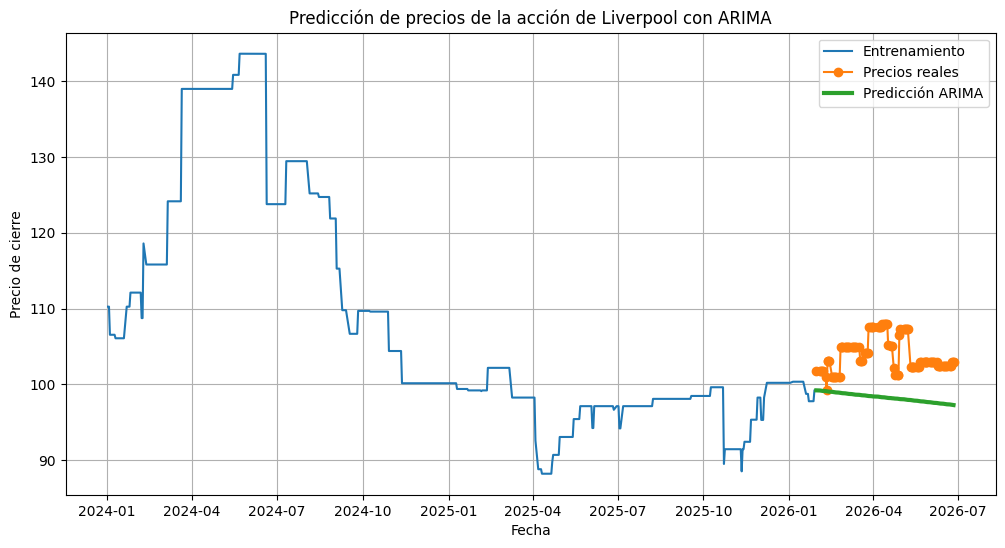

In [204]:
plt.figure(figsize=(12,6))

# Datos de entrenamiento
plt.plot(train.index, train,
         label='Entrenamiento')

# Datos reales
plt.plot(test.index, test,
         marker='o', label='Precios reales')

# Predicción
plt.plot(test.index, pprecios_pred,
        linewidth=3, label='Predicción ARIMA')

plt.title('Predicción de precios de la acción de Liverpool con ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)

plt.show()

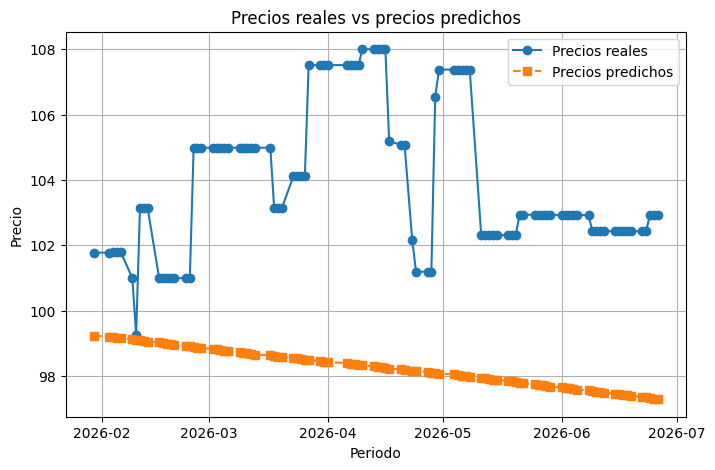

In [205]:
plt.figure(figsize=(8,5))

plt.plot(precios_reales.index, precios_reales,
         marker='o', label='Precios reales')

plt.plot(precios_reales.index, pprecios_pred,
         marker='s', linestyle='--', label='Precios predichos')

plt.title('Precios reales vs precios predichos')
plt.xlabel('Periodo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

##Estadísticos de Bondad de Ajuste

###Error Cuadrático Medio (MAE)

In [206]:
mae = mean_absolute_error(precios_reales, pprecios_pred)
print(f"MAE = {mae: .2f}")

MAE =  5.60


In [207]:
mae_porcentaje = (mae /precios_reales.mean()) * 100
print(f"% MAE ARIMA: {mae_porcentaje:.4f} %")

% MAE ARIMA: 5.3921 %


###Error Cuadrático Medio (RMSE)

In [208]:
rmse = np.sqrt(mean_squared_error(precios_reales, pprecios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 6.04


In [209]:
rmse_porcentaje = (rmse / precios_reales.mean()) * 100
print(f"% RMSE ARIMA: {rmse_porcentaje:.4f} %")

% RMSE ARIMA: 5.8174 %


###Error Porcentual Absoluto Medio (MAPE)

In [210]:
mape = mean_absolute_percentage_error(precios_reales, pprecios_pred) * 100
print(f"MAPE ARIMA= {mape: .4f} %")

MAPE ARIMA=  5.3500 %


#Predicción de Precio del día siguiente (29/06/26)


In [176]:
#Alineamos la serie original con frecuencia de días hábiles ('B') para corregir el índice temporal
rendimientos_con_freq = df['Rendimientos_Log'].dropna().asfreq('B', method='bfill')

In [177]:
#Reajustamos el modelo ARIMA con los datos alineados
modelo_temp = ARIMA(rendimientos_con_freq, order=(0,0,0))
resultado_temp = modelo_temp.fit()

In [178]:
#Realizamos el pronóstico sin problemas de índices
prediction = resultado_temp.forecast(steps=1)
print(prediction)

2026-06-29   -0.000199
Freq: B, dtype: float64


In [179]:
#Vamos a convertir los rendimientos en precios
ultimo_precio = precios.iloc[-1]   # Último precio conocido

precio_pred = []
precio_actual = ultimo_precio

for r in prediction:
    precio_actual = precio_actual * np.exp(r)
    precio_pred.append(precio_actual)

In [180]:
#Prediccion precio del siguiente día de cotizacion (29/06/26)
#Al imprimir aparece la fecha del 26, pero la fecha que se predijo es la del 29/06/2026
precio_pred = pd.Series(precio_pred, index=prediction.index)

print(precio_pred)

2026-06-29    102.902065
Freq: B, dtype: float64


####Hacer comparación día siguiente

In [182]:
#Vamos a extraer el ultimo precio, el del día 29-06-26
#Obtener datos
hoy = yf.download('LIVEPOL1.MX', start='2026-06-27', end ='2026-06-30')

/tmp/ipykernel_1856/2665990279.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hoy = yf.download('LIVEPOL1.MX', start='2026-06-27', end ='2026-06-30')
[*********************100%***********************]  1 of 1 completed


In [183]:
# Eliminar nivel del ticker
hoy.columns = hoy.columns.droplevel(1)

In [184]:
Precio_hoy = hoy['Close']
print(Precio_hoy)

Date
2026-06-29    102.922569
Name: Close, dtype: float64


In [185]:
#Para almacenar los datos por cualquier cosa
hoy.to_csv("LIVEPOL1.MX_29_06_26.csv")

In [186]:
comparacion1 = pd.DataFrame({
    "Real": Precio_hoy,
    "Pronosticado": precio_pred
})

print(comparacion1)

                  Real  Pronosticado
2026-06-29  102.922569    102.902065


##Estadísticos Bonda de Ajuste

###Error Cuadrático Medio (MAE)

In [187]:
mae = mean_absolute_error(hoy['Close'], precio_pred)
print(f"MAE = {mae: .2f}")

MAE =  0.02


In [188]:
mae_porcentaje = (mae / Precio_hoy) * 100
print(f"% MAE ARIMA: {mae_porcentaje.iloc[0]:.4f} %")

% MAE ARIMA: 0.0199 %


###Error Cuadrático Medio (RMSE)

In [189]:
rmse = np.sqrt(mean_squared_error(hoy['Close'], precio_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 0.02


In [190]:
rmse_porcentaje = (rmse / Precio_hoy) * 100
print(f"% RMSE ARIMA: {rmse_porcentaje.iloc[0]:.4f} %")

% RMSE ARIMA: 0.0199 %


###Error Porcentual Absoluto Medio (MAPE)

In [191]:
mape = mean_absolute_percentage_error(hoy['Close'], precio_pred) * 100
print(f"MAPE = {mape: .4f} %")

MAPE =  0.0199 %


#Predicción para 100 días desde el 29/06/26

In [160]:
# Ajustamos el modelo con los rendimientos que sí tienen frecuencia temporal ('B') y realizamos el pronóstico
modelo_freq = ARIMA(rendimientos_con_freq, order=(0, 0, 1))
resultado_freq = modelo_freq.fit()

predictions = resultado_freq.forecast(steps=100)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [161]:
ultimo_precio = precios.iloc[-1]

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [162]:
fechas_pred = pd.date_range(
    start='2026-06-29',
    periods=100,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [163]:
pronosticos = pd.DataFrame({
    "Fecha": fechas_pred,
    "Precio pronosticado": precios_pred
})

print(pronosticos)

        Fecha  Precio pronosticado
0  2026-06-29           102.902103
1  2026-06-30           102.881726
2  2026-07-01           102.861354
3  2026-07-02           102.840985
4  2026-07-03           102.820621
..        ...                  ...
95 2026-11-09           100.984235
96 2026-11-10           100.964239
97 2026-11-11           100.944246
98 2026-11-12           100.924257
99 2026-11-13           100.904272

[100 rows x 2 columns]


In [164]:
print(pronosticos.to_string())

        Fecha  Precio pronosticado
0  2026-06-29           102.902103
1  2026-06-30           102.881726
2  2026-07-01           102.861354
3  2026-07-02           102.840985
4  2026-07-03           102.820621
5  2026-07-06           102.800260
6  2026-07-07           102.779904
7  2026-07-08           102.759552
8  2026-07-09           102.739203
9  2026-07-10           102.718859
10 2026-07-13           102.698519
11 2026-07-14           102.678182
12 2026-07-15           102.657850
13 2026-07-16           102.637522
14 2026-07-17           102.617198
15 2026-07-20           102.596878
16 2026-07-21           102.576562
17 2026-07-22           102.556250
18 2026-07-23           102.535941
19 2026-07-24           102.515637
20 2026-07-27           102.495337
21 2026-07-28           102.475041
22 2026-07-29           102.454749
23 2026-07-30           102.434461
24 2026-07-31           102.414177
25 2026-08-03           102.393897
26 2026-08-04           102.373622
27 2026-08-05       

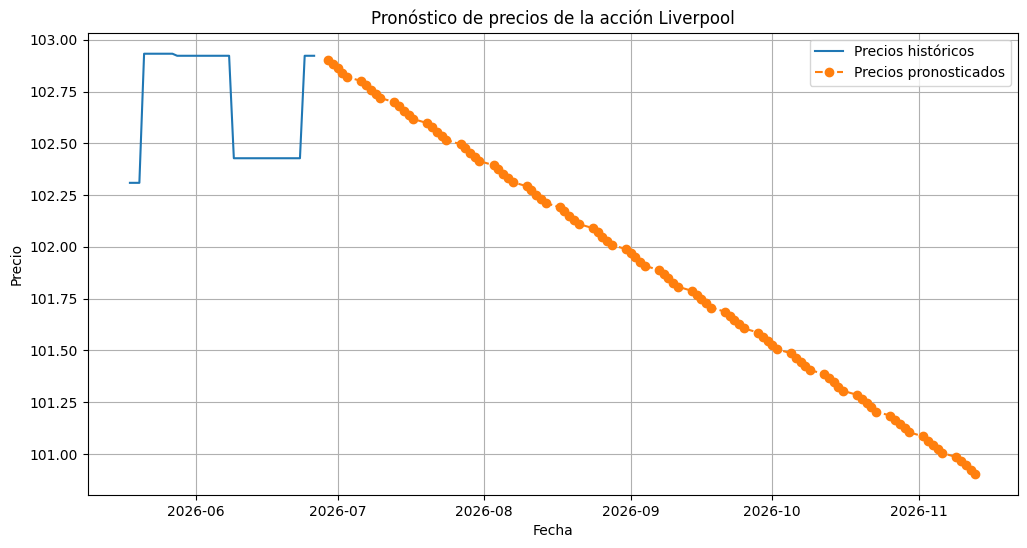

In [165]:
plt.figure(figsize=(12,6))

# Últimos precios históricos
plt.plot(precios.index[-30:], precios[-30:], label='Precios históricos')

# Predicciones
plt.plot(fechas_pred, precios_pred,
         marker='o',
         linestyle='--',
         label='Precios pronosticados')

plt.title('Pronóstico de precios de la acción Liverpool')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()